In [3]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import PhaseOracle
from qiskit_algorithms import Grover, AmplificationProblem
import numpy as np

In [13]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# PARAMETER
# ===============================
n = len(target)  # jumlah qubit sesuai panjang target
target = "1011" # contoh target
iterations = int(np.pi / 4 * np.sqrt(2**n))  # jumlah iterasi optimal untuk Grover

# ===============================
# ORACLE (phase flip target)
# ===============================
def grover_oracle(n, target):
    oracle = QuantumCircuit(n)

    # Flip qubit jika target bit = 0
    for i, bit in enumerate(target):
        if bit == "0":
            oracle.x(i)

    # Multi-controlled Z
    oracle.h(n-1)
    oracle.mcx(list(range(n-1)), n-1)
    oracle.h(n-1)

    # Balikkan X tadi
    for i, bit in enumerate(target):
        if bit == "0":
            oracle.x(i)

    return oracle

# ===============================
# DIFFUSER
# ===============================
def diffuser(n):
    diff = QuantumCircuit(n)

    diff.h(range(n))
    diff.x(range(n))

    diff.h(n-1)
    diff.mcx(list(range(n-1)), n-1)
    diff.h(n-1)

    diff.x(range(n))
    diff.h(range(n))

    return diff

# ===============================
# BUILD GROVER CIRCUIT
# ===============================
qc = QuantumCircuit(n)

# Superposition awal
qc.h(range(n))

oracle = grover_oracle(n, target)
diff = diffuser(n)

# Iterasi Grover
for _ in range(iterations):
    qc.compose(oracle, inplace=True)
    qc.compose(diff, inplace=True)

# ===============================
# SAVE STATEVECTOR
# ===============================
qc.save_statevector()

sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled).result()

statevector = np.array(result.data(0)["statevector"])

print("Dimensi statevector:", len(statevector))

Dimensi statevector: 8


In [14]:
print(target)

1011


In [ ]:
probabilities = np.abs(statevector)**2

max_index = np.argmax(probabilities)
max_prob = probabilities[max_index]

solution_state = format(max_index, f"0{n}b")

print("State dominan :", solution_state)
print("Probabilitas  :", max_prob)

State dominan : 101
Probabilitas  : 0.9453125000000001


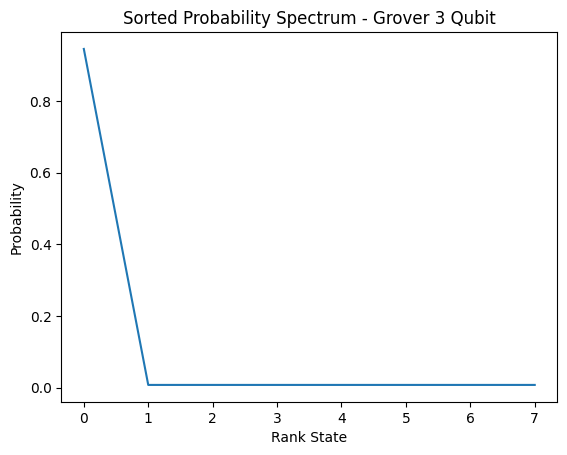

In [ ]:
sorted_probs = np.sort(probabilities)[::-1]

plt.figure()
plt.plot(sorted_probs)
plt.xlabel("Rank State")
plt.ylabel("Probability")
plt.title(f"Sorted Probability Spectrum - Grover {n} Qubit")
plt.show()